In [1]:
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import SBVGPResult2, SIResult, FlowPriorResult
from experiments.dj.dataloader_tables import DataLoaderConfig

from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl

import torch
import matplotlib.pyplot as plt

import pickle
import seaborn as sns


from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import SBVGPResult2, SIResult, FlowPriorResult
from experiments.dj.dataloader_tables import DataLoaderConfig

from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl

# import torch
import datajoint as dj
from experiments.dj.dataloader_tables import DataLoaderConfig, AltDataLoaderConfig
from experiments.dj.schema import schema
from experiments.dj.likelihood_tables import LikelihoodConfig

from experiments.dj.prior_tables import FlowPriorConfig, AdaptPriorConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.result_tables import (
    FlowPriorResult,
    FPSamples,
    FPSamplesConfig,
    LikelihoodResult,
    MLPCondSamples2,
    MLPCondSamplesConfig2,
    SBVGPResult2,
    SIResult,
    AdaptPriorResult,
    AdaptPriorSamplesConfig,
    SBVGPAdaptedResult,
)
from experiments.dj.evaluation_tables import SIEval, SBVGPEval
from experiments.dj.trainer_tables import (
    FPTrainerConfig,
    LLTrainerConfig,
    SBVGPTrainerConfig,
    SITrainerConfig,
    AdaptPriorTrainer,
)
from experiments.dj.dj_helpers import drop_schema_dot_jobs
from experiments.dj.dj_helpers import fetch_best_model_results
from task_transfer.ml_lib.data_loading import build_dataloaders

from collections import OrderedDict
from task_transfer.utils.utils import dict_product
from experiments.dj.evaluation_tables import FlowPriorEval

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from task_transfer.ml_lib.data_loading import (
    build_dataloaders,
    build_dataloaders_from_samples_paths,
)


torch.manual_seed(42)

[2024-08-24 18:12:19,755][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-08-24 18:12:19,762][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
restriction = "dl_id = 'f7b32dd97feda9f34e2b47e24fa3d18b'"
best_si = (SIResult & restriction).fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True
)[0]
sbv_restriction = restriction + " and n_samples = 10000"
best_sbv = (SBVGPResult2 & sbv_restriction).fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True
)[0]

best_si_model = torch.load(best_si["model"], map_location="cpu")
best_sbv_model = torch.load(best_sbv["model"], map_location="cpu")

In [3]:
best_si_model

IndependentGamma(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.gamma.Gamma'>, event_dims=1
    (parameter_generator): ConcRate(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=144, out_features=1, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): ReLU()
          (linear_1): Linear(in_features=1, out_features=1, bias=True)
          (dropout_1): Dropout(p=0.0, inplace=False)
          (nonlin_1): ReLU()
        )
      )
      (conc_module): Linear(in_features=1, out_features=1, bias=True)
      (rate_module): Linear(in_features=1, out_features=1, bias=True)
    )
  )
)

In [4]:
best_sbv_model

IndependentGamma(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.gamma.Gamma'>, event_dims=1
    (parameter_generator): ConcRate(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=144, out_features=1, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): ReLU()
          (linear_1): Linear(in_features=1, out_features=1, bias=True)
          (dropout_1): Dropout(p=0.0, inplace=False)
          (nonlin_1): ReLU()
        )
      )
      (conc_module): Linear(in_features=1, out_features=1, bias=True)
      (rate_module): Linear(in_features=1, out_features=1, bias=True)
    )
  )
)

In [5]:
dataloader_config = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_1neuron_highdelta_task1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_config["data_fname"],
    train_prop=dataloader_config["train_prop"],
    val_prop=dataloader_config["val_prop"],
    batch_size=dataloader_config["batch_size"],
)

In [6]:
# orientations = torch.tensor([0.0])
orientations = torch.linspace(0, torch.pi, steps=45 + 1)[:-1][::11]
obs_h, obs_w = 12, 12
gabor_params = dict(
    {
        "canvas_size": [obs_h, obs_w],
        "sizes": [10],
        "spatial_frequencies": [1 / 3],
        "contrasts": [1.0],
        "grey_levels": [0.0],
        "eccentricities": [0.0],
        "locations": [[6, 6]],
        "phases": [torch.pi / 2],
        "relative_sf": False,
    },
)
stimuli = torch.Tensor(
    generate_gabors(orientations=orientations.tolist(), gabor_params=gabor_params)
)

In [7]:
stimuli.shape

torch.Size([5, 12, 12])

In [8]:
best_si_model

IndependentGamma(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.gamma.Gamma'>, event_dims=1
    (parameter_generator): ConcRate(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=144, out_features=1, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): ReLU()
          (linear_1): Linear(in_features=1, out_features=1, bias=True)
          (dropout_1): Dropout(p=0.0, inplace=False)
          (nonlin_1): ReLU()
        )
      )
      (conc_module): Linear(in_features=1, out_features=1, bias=True)
      (rate_module): Linear(in_features=1, out_features=1, bias=True)
    )
  )
)

In [9]:
stimuli.shape

torch.Size([5, 12, 12])

In [10]:
best_si_model.eval()
best_sbv_model.eval()
si_pdfs = []
sbv_pdfs = []
zero = torch.finfo(torch.float32).eps
x = torch.linspace(zero, 6, steps=1000).unsqueeze(-1)
for stimulus in stimuli:
    with torch.no_grad():
        si_dist = best_si_model.trainable_distribution.distribution(cond=stimulus.reshape(-1, obs_h * obs_w))
        si_pdfs.append(si_dist.log_prob(x).exp())
        sbv_dist = best_sbv_model.trainable_distribution.distribution(cond=stimulus.reshape(-1, obs_h * obs_w))
        sbv_pdfs.append(sbv_dist.log_prob(x).exp())

In [11]:
si_pdfs = torch.stack(si_pdfs)

In [12]:
sbv_pdfs = torch.stack(sbv_pdfs)

/tmp/ipykernel_1601283/3596153774.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3675.)
  plt.plot(x.flatten(), sbv_pdfs[0].T, label="SBV", color="blue")


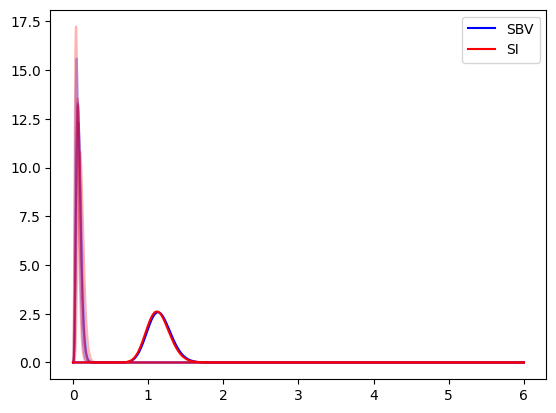

In [13]:
plt.plot(x.flatten(), sbv_pdfs[0].T, label="SBV", color="blue")
plt.plot(x.flatten(), sbv_pdfs[1:].T, color="blue", alpha=0.3)
plt.plot(x.flatten(), si_pdfs[0].T, label="SI", color="red")
plt.plot(x.flatten(), si_pdfs[1:].T, color="red", alpha=0.3)
plt.legend()

In [15]:
best_si

{'si_id': '6deb07682dd4919b2ebe01c255b23445',
 'trainer_id': 'a2a0e79d4c785fead2a84d56420b6063',
 'dl_id': 'f7b32dd97feda9f34e2b47e24fa3d18b',
 'train_ll_mean': 0.5538503527641296,
 'train_ll_sem': 0.22692462801933289,
 'val_ll_mean': 0.44139471650123596,
 'val_ll_sem': 0.5243037939071655,
 'test_ll_mean': 0.4025052487850189,
 'test_ll_sem': 0.7082290053367615,
 'tracker_output': '/tmp/ce63873b5cf853e83d343addbedbbfe2_tracker_output_0000.pkl',
 'eval_output': '/tmp/ce63873b5cf853e83d343addbedbbfe2_eval_output.pkl',
 'model': '/tmp/ce63873b5cf853e83d343addbedbbfe2_model_0000.pt'}

In [15]:
si_config = (SIConfig & "id = '6deb07682dd4919b2ebe01c255b23445'").fetch1()

In [16]:
si_config

{'id': '6deb07682dd4919b2ebe01c255b23445',
 'seed': 100,
 'cond_dist': 'gamma',
 'nonneg_transform': 'exp',
 'n_layers': 3,
 'nonlin': 'relu',
 'dropout_rate': 0.0,
 'init_std': 0.001,
 'kwargs': {'clamp_pre_conc': True,
  'pre_conc_max': 4.0,
  'clamp_pre_rate': True,
  'pre_rate_min': -1.6}}

In [17]:
best_sbv

{'sbvp_id': '77941396a735dc6ee02bcdf4b24896e7',
 'sbvp_trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'fp_samples_id': '89c1053a65023b042dc63f7f852bb5b0',
 'dl_id': 'f7b32dd97feda9f34e2b47e24fa3d18b',
 'trainer_id': 'c40a50ce9c77369770dddd5129836477',
 'data_seed': 42,
 'n_samples': 10000,
 'mlpcond_samples_id': 'a67b8eaff13e89e7272e90768c2ab280',
 'll_trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'train_ll_mean': 0.5242013335227966,
 'train_ll_sem': 0.23360812664031982,
 'val_ll_mean': 0.4427397847175598,
 'val_ll_sem': 0.5255548357963562,
 'test_ll_mean': 0.3845190703868866,
 'test_ll_sem': 0.7051239013671875,
 'train_ll_mean_sample': 0.492057204246521,
 'train_ll_sem_sample': 0.3346768617630005,
 'val_ll_mean_sample': 0.42926648259162903,
 'val_ll_sem_sample': 0.6960524916648865,
 'test_ll_mean_sample': 0.45057594776153564,
 'test_ll_sem_sample': 0.5513153672218323,
 'tracker_output': '/tmp/a22d1bd5155513d18f6a944203cf02fb_tracker_output.pkl',
 'eval_output': '/tmp/a22d1bd515

In [18]:
sbv_config = (SBVGPConfig & "id = '77941396a735dc6ee02bcdf4b24896e7'").fetch1()

In [19]:
sbv_config, si_config

({'id': '77941396a735dc6ee02bcdf4b24896e7',
  'seed': 100,
  'nonneg_transform': 'exp',
  'n_layers': 3,
  'nonlin': 'relu',
  'dropout_rate': 0.0,
  'init_std': 0.001,
  'kwargs': {'clamp_pre_conc': True,
   'pre_conc_max': 4.0,
   'clamp_pre_rate': True,
   'pre_rate_min': -1.6}},
 {'id': '6deb07682dd4919b2ebe01c255b23445',
  'seed': 100,
  'cond_dist': 'gamma',
  'nonneg_transform': 'exp',
  'n_layers': 3,
  'nonlin': 'relu',
  'dropout_rate': 0.0,
  'init_std': 0.001,
  'kwargs': {'clamp_pre_conc': True,
   'pre_conc_max': 4.0,
   'clamp_pre_rate': True,
   'pre_rate_min': -1.6}})

In [20]:
best_si["dl_id"] == best_sbv["dl_id"]

True

In [25]:
best_sbv

{'sbvp_id': '77941396a735dc6ee02bcdf4b24896e7',
 'sbvp_trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'fp_samples_id': '89c1053a65023b042dc63f7f852bb5b0',
 'dl_id': 'f7b32dd97feda9f34e2b47e24fa3d18b',
 'trainer_id': 'c40a50ce9c77369770dddd5129836477',
 'data_seed': 42,
 'n_samples': 10000,
 'mlpcond_samples_id': 'a67b8eaff13e89e7272e90768c2ab280',
 'll_trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'train_ll_mean': 0.5242013335227966,
 'train_ll_sem': 0.23360812664031982,
 'val_ll_mean': 0.4427397847175598,
 'val_ll_sem': 0.5255548357963562,
 'test_ll_mean': 0.3845190703868866,
 'test_ll_sem': 0.7051239013671875,
 'train_ll_mean_sample': 0.492057204246521,
 'train_ll_sem_sample': 0.3346768617630005,
 'val_ll_mean_sample': 0.42926648259162903,
 'val_ll_sem_sample': 0.6960524916648865,
 'test_ll_mean_sample': 0.45057594776153564,
 'test_ll_sem_sample': 0.5513153672218323,
 'tracker_output': '/tmp/a22d1bd5155513d18f6a944203cf02fb_tracker_output.pkl',
 'eval_output': '/tmp/a22d1bd515

In [36]:
fpsamples = (FPSamples & f"fp_id = '{best_sbv['fp_samples_id']}' and dl_id = '{best_sbv['dl_id']}' and seed = {best_sbv['data_seed']} and n_samples = {best_sbv['n_samples']}").fetch1(download_path="/tmp")

In [38]:
sim_prior_samples = torch.load(fpsamples["samples"], map_location="cpu")

In [40]:
sim_prior_samples.shape

torch.Size([10000, 1])

In [43]:
real_data_fname = (DataLoaderConfig & f"id = '{best_si['dl_id']}'").fetch1()["data_fname"]

In [46]:
with open(real_data_fname, "rb") as f:
    real_data = pickle.load(f)

In [48]:
real_prior_samples = real_data["x_samples"]

In [49]:
real_prior_samples.shape

torch.Size([10000, 1])

(0.0, 8.0)

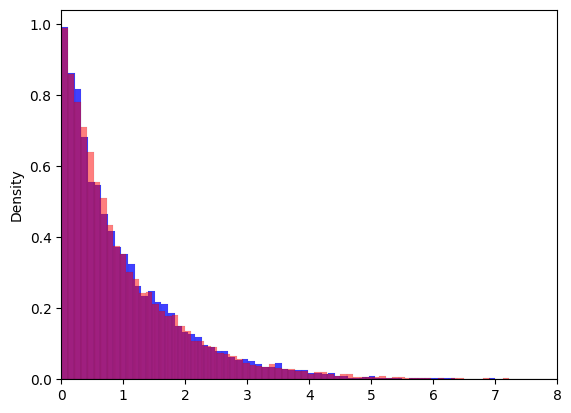

In [56]:
sns.histplot(sim_prior_samples.flatten(), stat="density", color="blue")
sns.histplot(real_prior_samples.flatten(), stat="density", color="red", alpha=0.5)
plt.xlim(0, 8)

In [57]:
data_loader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_1neuron_highdelta_task1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}

train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=data_loader_args["data_fname"],
    train_prop=data_loader_args["train_prop"],
    val_prop=data_loader_args["val_prop"],
    batch_size=data_loader_args["batch_size"],
)

In [61]:
best_sbv

{'sbvp_id': '77941396a735dc6ee02bcdf4b24896e7',
 'sbvp_trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'fp_samples_id': '89c1053a65023b042dc63f7f852bb5b0',
 'dl_id': 'f7b32dd97feda9f34e2b47e24fa3d18b',
 'trainer_id': 'c40a50ce9c77369770dddd5129836477',
 'data_seed': 42,
 'n_samples': 10000,
 'mlpcond_samples_id': 'a67b8eaff13e89e7272e90768c2ab280',
 'll_trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'train_ll_mean': 0.5242013335227966,
 'train_ll_sem': 0.23360812664031982,
 'val_ll_mean': 0.4427397847175598,
 'val_ll_sem': 0.5255548357963562,
 'test_ll_mean': 0.3845190703868866,
 'test_ll_sem': 0.7051239013671875,
 'train_ll_mean_sample': 0.492057204246521,
 'train_ll_sem_sample': 0.3346768617630005,
 'val_ll_mean_sample': 0.42926648259162903,
 'val_ll_sem_sample': 0.6960524916648865,
 'test_ll_mean_sample': 0.45057594776153564,
 'test_ll_sem_sample': 0.5513153672218323,
 'tracker_output': '/tmp/a22d1bd5155513d18f6a944203cf02fb_tracker_output.pkl',
 'eval_output': '/tmp/a22d1bd515

In [64]:
MLPCondSamples2()

fp_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,seed,n_samples,ll_id from LikelihoodResult,ll_trainer_id from LikelihoodResult and LLTrainerConfig,samples
89c1053a65023b042dc63f7f852bb5b0,f7b32dd97feda9f34e2b47e24fa3d18b,c40a50ce9c77369770dddd5129836477,42,10000,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,=BLOB=
89c1053a65023b042dc63f7f852bb5b0,f7b32dd97feda9f34e2b47e24fa3d18b,c40a50ce9c77369770dddd5129836477,42,20000,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,=BLOB=
89c1053a65023b042dc63f7f852bb5b0,f1ae78885d2ace1ba976199d4cf1a4d6,c40a50ce9c77369770dddd5129836477,42,10000,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,=BLOB=
89c1053a65023b042dc63f7f852bb5b0,f1ae78885d2ace1ba976199d4cf1a4d6,c40a50ce9c77369770dddd5129836477,42,20000,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,=BLOB=
89c1053a65023b042dc63f7f852bb5b0,f7b32dd97feda9f34e2b47e24fa3d18b,c40a50ce9c77369770dddd5129836477,42,30000,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,=BLOB=
89c1053a65023b042dc63f7f852bb5b0,f1ae78885d2ace1ba976199d4cf1a4d6,c40a50ce9c77369770dddd5129836477,42,50000,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,=BLOB=
89c1053a65023b042dc63f7f852bb5b0,f7b32dd97feda9f34e2b47e24fa3d18b,c40a50ce9c77369770dddd5129836477,42,50000,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,=BLOB=
89c1053a65023b042dc63f7f852bb5b0,f1ae78885d2ace1ba976199d4cf1a4d6,c40a50ce9c77369770dddd5129836477,42,30000,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,=BLOB=


In [67]:
fpsamples_path = (
    FPSamples
    & f"fp_id = '{best_sbv['fp_samples_id']}' and dl_id = '{best_sbv['dl_id']}' and seed = {best_sbv['data_seed']} and n_samples = {best_sbv['n_samples']}"
).fetch1(download_path="/tmp")["samples"]

mlpsamples_path = (
    MLPCondSamples2
    & f"ll_id = '{best_sbv['mlpcond_samples_id']}' and dl_id = '{best_sbv['dl_id']}' and n_samples = {best_sbv['n_samples']}"
).fetch1(download_path="/tmp")["samples"]

In [74]:
data_loader_args.update(
    {
        "sampled_responses_path": fpsamples_path,
        "sampled_obs_path": mlpsamples_path,
        "data_seed": best_sbv["data_seed"],
    }
)

samples_train_loader, samples_val_loader, samples_test_loader = (
    build_dataloaders_from_samples_paths(
        response_samples_path=data_loader_args["sampled_responses_path"],
        obs_samples_path=data_loader_args["sampled_obs_path"],
        train_prop=data_loader_args["train_prop"],
        val_prop=data_loader_args["val_prop"],
        batch_size=data_loader_args["batch_size"],
        seed=data_loader_args["data_seed"],
    )
)

In [75]:
sample_train_responses = torch.cat([x for x, _ in samples_train_loader])
real_train_responses = torch.cat([x for x, _ in train_loader])
sample_val_responses = torch.cat([x for x, _ in samples_val_loader])
real_val_responses = torch.cat([x for x, _ in val_loader])
sample_test_responses = torch.cat([x for x, _ in samples_test_loader])
real_test_responses = torch.cat([x for x, _ in test_loader])

In [76]:
sample_train_responses.shape, real_train_responses.shape, sample_val_responses.shape, real_val_responses.shape, sample_test_responses.shape, real_test_responses.shape

(torch.Size([7000, 1]),
 torch.Size([7000, 1]),
 torch.Size([2000, 1]),
 torch.Size([2000, 1]),
 torch.Size([1000, 1]),
 torch.Size([1000, 1]))

(0.0, 8.0)

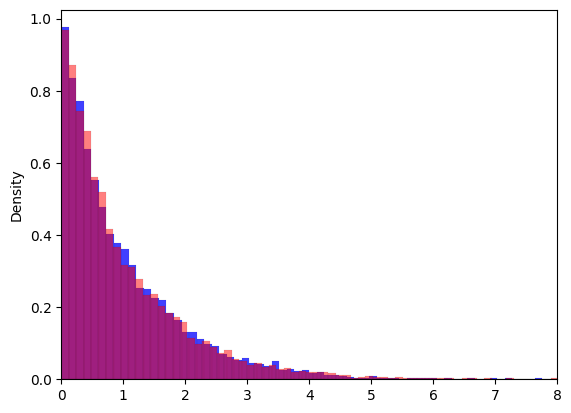

In [78]:
sns.histplot(sample_train_responses.flatten(), stat="density", color="blue")
sns.histplot(real_train_responses.flatten(), stat="density", color="red", alpha=0.5)
plt.xlim(0, 8)

(0.0, 8.0)

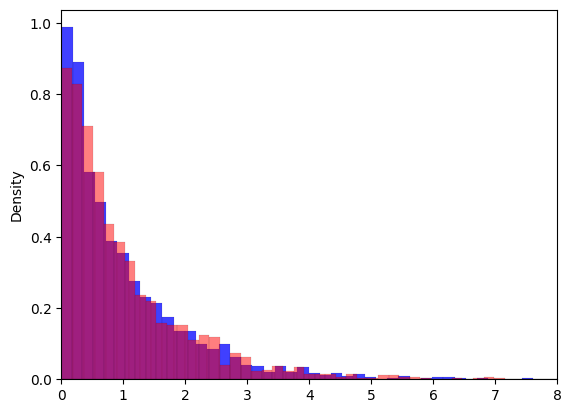

In [79]:
sns.histplot(sample_val_responses.flatten(), stat="density", color="blue")
sns.histplot(real_val_responses.flatten(), stat="density", color="red", alpha=0.5)
plt.xlim(0, 8)

(0.0, 8.0)

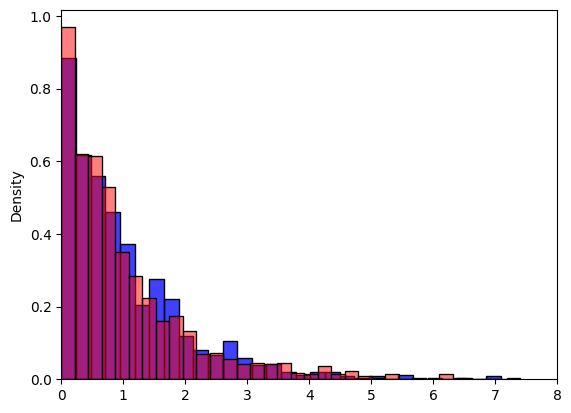

In [80]:
sns.histplot(sample_test_responses.flatten(), stat="density", color="blue")
sns.histplot(real_test_responses.flatten(), stat="density", color="red", alpha=0.5)
plt.xlim(0, 8)

In [85]:
SBVGPTrainerConfig & f"id = '{best_sbv['sbvp_trainer_id']}'"

id,lr,weight_decay,n_epochs,batch_size,early_stopping_threshold,early_stopping_patience
f89651063b51487dcdf4041336ef89db,0.001,0.001,250,128,10,10


In [87]:
SITrainerConfig & f"id = '{best_si['trainer_id']}'"

id,lr,weight_decay,n_epochs,batch_size,early_stopping_threshold,early_stopping_patience
a2a0e79d4c785fead2a84d56420b6063,0.001,0.001,500,128,10,10
